In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

features_df = pd.read_csv("data/maize_owino_features.csv", parse_dates=["date"])

FEATURE_COLS = [
    "price_lag_1", "price_lag_2", "price_lag_3",
    "rolling_mean_3", "rolling_mean_6",
    "month", "year"
]

train = features_df[features_df["year"] <= 2019].copy()
test  = features_df[features_df["year"] >= 2020].copy()

X_train = train[FEATURE_COLS]
y_train = train["target"]
X_test  = test[FEATURE_COLS]
y_test  = test["target"]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")


X_train shape: (175, 7)
X_test shape:  (20, 7)


## Why Random Forest?

A **Random Forest** is one of the most reliable models for tabular data.
Here's how it works:

1. Build 100 **decision trees**, each trained on a random subset of the training rows
2. Each tree learns rules like: *"if lag_1 > 800 AND month is March → predict 950"*
3. To predict, run the input through all 100 trees and average the results

**Why this is better than one tree:**
One tree tends to **overfit** — it memorises the training data perfectly but
fails on new data. Averaging 100 trees cancels out individual errors. This is
called an **ensemble**.

**Hyperparameters we're setting:**
- `n_estimators=100` — number of trees (more = more stable, slower to train)
- `random_state=42` — makes results reproducible (same shuffle every run)


In [2]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Training complete.")
print(f"Number of trees: {model.n_estimators}")
print(f"Features the model knows about: {FEATURE_COLS}")


Training complete.
Number of trees: 100
Features the model knows about: ['price_lag_1', 'price_lag_2', 'price_lag_3', 'rolling_mean_3', 'rolling_mean_6', 'month', 'year']


In [7]:
import joblib

joblib.dump(model, "maize_price_model.pkl")
print("Model saved to maize_price_model.pkl")


Model saved to maize_price_model.pkl


In [3]:
y_train_pred = model.predict(X_train)
train_mae = mean_absolute_error(y_train, y_train_pred)
print(f"Train MAE: {train_mae:,.0f} UGX/kg")


Train MAE: 57 UGX/kg


In [4]:
y_test_pred = model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
avg_test_price = y_test.mean()

print(f"Test MAE:  {test_mae:,.0f} UGX/kg")
print(f"Avg test price: {avg_test_price:,.0f} UGX/kg")
print(f"Error as % of avg price: {test_mae / avg_test_price * 100:.1f}%")


Test MAE:  193 UGX/kg
Avg test price: 932 UGX/kg
Error as % of avg price: 20.7%


## Reading the results

| Metric | Value | What it means |
|--------|-------|---------------|
| Train MAE | 57 UGX/kg | Model nearly memorised training data |
| Test MAE | 193 UGX/kg | Real-world performance on unseen data |

The gap between train and test MAE is called **overfitting**.
The model learned the training data too well and struggles to generalise.

**Is this test MAE acceptable?**
Test MAE is 193 UGX/kg against an average price of 932 UGX/kg — about 20% off.
For a first model on real-world data with gaps, that's a reasonable baseline.
We could reduce overfitting by limiting tree depth (`max_depth=5`) — but
for this learning project, the baseline result is the goal.


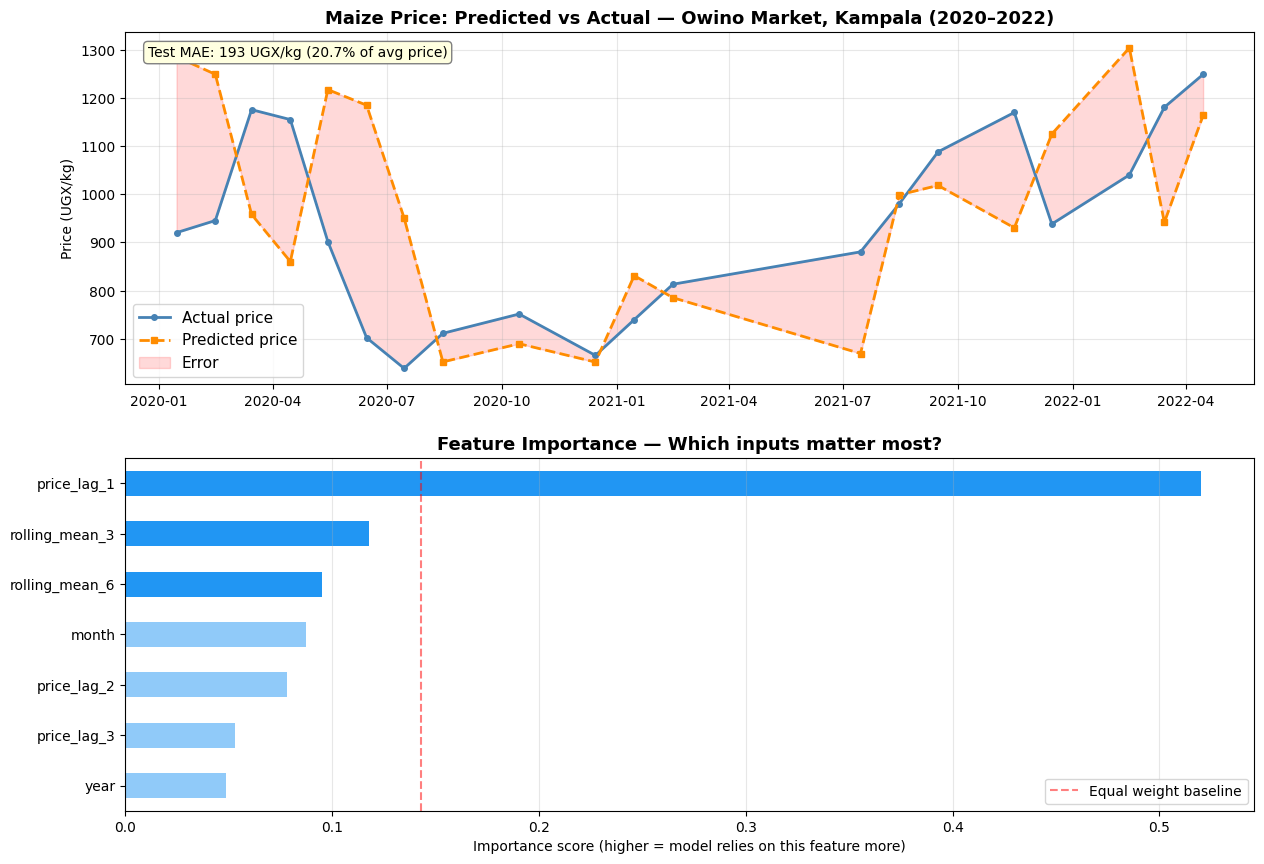

Chart saved to price_prediction_results.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# --- Chart 1: Predicted vs Actual ---
axes[0].plot(test["date"], y_test.values, label="Actual price",
             color="steelblue", linewidth=2, marker="o", markersize=4)
axes[0].plot(test["date"], y_test_pred, label="Predicted price",
             color="darkorange", linewidth=2, linestyle="--", marker="s", markersize=4)
axes[0].fill_between(test["date"], y_test.values, y_test_pred,
                     alpha=0.15, color="red", label="Error")
axes[0].set_title("Maize Price: Predicted vs Actual — Owino Market, Kampala (2020–2022)",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Price (UGX/kg)")
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f"Test MAE: {test_mae:,.0f} UGX/kg ({test_mae/avg_test_price*100:.1f}% of avg price)",
                 xy=(0.02, 0.93), xycoords="axes fraction", fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"))

# --- Chart 2: Feature Importance ---
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
colors = ["#2196F3" if i >= len(importance) - 3 else "#90CAF9" for i in range(len(importance))]
importance.plot(kind="barh", ax=axes[1], color=colors)
axes[1].set_title("Feature Importance — Which inputs matter most?", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Importance score (higher = model relies on this feature more)")
axes[1].axvline(x=1/len(FEATURE_COLS), color="red", linestyle="--", alpha=0.5, label="Equal weight baseline")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout(pad=2)
plt.savefig("price_prediction_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to price_prediction_results.png")


## Reading the Feature Importance chart

**Feature importance** tells you how much each input influenced the model's decisions
across all 100 trees. Higher = the model relied on this feature more.

Typical result for price prediction:
- `price_lag_1` dominates — last month's price is the strongest signal
- `rolling_mean_3` / `rolling_mean_6` come next — trend matters
- `month` ranks above `year` — seasonality is a real pattern in the data
- `price_lag_2` and `price_lag_3` are weaker — the model mostly cares about recent history

This confirms our intuition: **price momentum + seasonality = most of the story**.


## Why the predictions are off in 2020–2022

The model was trained on 2006–2019 data — normal market conditions.
The test period (2020–2022) covers COVID-19, which caused:
- Supply chain disruptions
- Border closures
- Lockdowns affecting transport and trade

The model had never seen anything like this. It predicts based on historical
patterns (seasonality, trend, momentum) which broke down during COVID.

This is a fundamental limitation of classical ML — **it cannot predict
events outside its training distribution**. The world changed, the model didn't.

A lower MAE would be expected on non-disrupted data.


In [6]:
print("=" * 50)
print("MODEL SUMMARY")
print("=" * 50)
print(f"Commodity:  Maize")
print(f"Market:     Owino (Kampala)")
print(f"Train set:  2006–2019  ({len(X_train)} months)")
print(f"Test set:   2020–2022  ({len(X_test)} months)")
print(f"Algorithm:  Random Forest ({model.n_estimators} trees)")
print()
print(f"Train MAE:  {train_mae:,.0f} UGX/kg")
print(f"Test MAE:   {test_mae:,.0f} UGX/kg")
print(f"Avg price:  {avg_test_price:,.0f} UGX/kg")
print(f"Error rate: {test_mae / avg_test_price * 100:.1f}%")
print()
print("Top feature by importance:")
top = pd.Series(model.feature_importances_, index=FEATURE_COLS).idxmax()
print(f"  {top}")


MODEL SUMMARY
Commodity:  Maize
Market:     Owino (Kampala)
Train set:  2006–2019  (175 months)
Test set:   2020–2022  (20 months)
Algorithm:  Random Forest (100 trees)

Train MAE:  57 UGX/kg
Test MAE:   193 UGX/kg
Avg price:  932 UGX/kg
Error rate: 20.7%

Top feature by importance:
  price_lag_1
